# Operator Learing - Fourier Neural Operator (FNO) in Neuromancer

This tutorial demonstrates the use of [FNOs](https://neuraloperator.github.io/dev/theory_guide/fno.html) for solving partial differential equations (PDEs) in the Neuromancer library.

This tutorial demonstrates the complete workflow of training a neural operator: 
1. Creating an FNO model architecture from scratch
2. Setting up `neuromancer.problem.Problem`
3. Training the model with Neuromancer `Trainer`
4. Evaluating predictions and zero-shot super-resolution

Example inspiration: https://github.com/camlab-ethz/AI_Science_Engineering/blob/main/Tutorial%2005%20-%20Operator%20Learing%20-%20Fourier%20Neural%20Operator.ipynb

<img src="https://neuraloperator.github.io/dev/_images/fourier_layer.jpg" width="600"> 

The Fourier layer just consists of three steps:
- Fourier transform $\mathcal{F}$
- Linear transform on the lower Fourier modes ${R}$
- Inverse Fourier transform $\mathcal{F}^{-1}$


### References

[1] [FNO theory guide - neuralop library](https://neuraloperator.github.io/dev/theory_guide/fno.html)

[2] [FNO paper](https://arxiv.org/abs/2010.08895)

[3] [ETH Zurich AI in the Sciences and Engineering](https://camlab-ethz.github.io/ai4s-course/)


## Problem Description - Allen-Cahn equation

The Governing Equation
We seek to solve the Allen-Cahn equation in the following form:
$$u_t =  \Delta u - \epsilon^2 u (u^2 - 1)$$
Where:
- $u(x, t)$ is the phase field variable (often representing concentration).
- $\epsilon$ is the parameter controlling the interface width between phases.
- $\Delta u$ represents the diffusion term.$(u^3 - u)$ is the derivative of the double-well potential, driving the system toward $u = \pm 1$.


Note that the data is generated (see the files *AC_data_input.npy* and *AC_data_output.npy*).

## The operator learning task

Unlike traditional solvers (Finite Difference or Finite Element), the Fourier Neural Operator (FNO) aims to learn the solution operator $\mathcal{G}$ in a resolution-independent manner:

$\mathcal{G}: u(\cdot, t = 0) \mapsto  u(\cdot, t = 1)$


## Install (Colab only)
Skip this step when running locally.

In [1]:
# !pip install neuromancer
# !pip install pyDOE

*Note: When running on Colab, one might encounter a pip dependency error with Lida 0.0.10. This can be ignored*

## Imports

In [ ]:
# torch and numpy imports
import torch
import torch.nn as nn
import numpy as np

# plotting imports
import matplotlib.pyplot as plt

# filter some user warnings from torch broadcast
import warnings

warnings.filterwarnings("ignore")

# system imports
import pathlib
import urllib.request


In [2]:
# Set default dtype to float32
torch.set_default_dtype(torch.float)
# PyTorch random number generator
torch.manual_seed(1234)

# Random number generators in other libraries
np.random.seed(1234)

# Device configuration
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cuda


### Get data of the exact solution
- Data source: (https://raw.githubusercontent.com/camlab-ethz/AI_Science_Engineering/main/datasets)
- Download if needed, save it in `./data/`

In [ ]:
# Download once (raw GitHub URLs)
data_dir = pathlib.Path("data/")
data_dir.mkdir(parents=True, exist_ok=True)
base = (
    "https://raw.githubusercontent.com/camlab-ethz/AI_Science_Engineering/main/datasets"
)
for fname in ("AC_data_input.npy", "AC_data_output.npy"):
    url = f"{base}/{fname}"
    dst = data_dir / fname
    if not dst.exists():
        urllib.request.urlretrieve(url, dst)

In [9]:
# Load tensors
x_data = torch.from_numpy(np.load(data_dir / "AC_data_input.npy")).float()
y_data = torch.from_numpy(np.load(data_dir / "AC_data_output.npy")).float()

print(f"Total data shape: {x_data.shape}, {y_data.shape}")

# Splits
n_train, n_val, n_test = 128, 32, 256
input_function_train = x_data[:n_train]
output_function_train = y_data[:n_train]
input_function_val = x_data[n_train : n_train + n_val]
output_function_val = y_data[n_train : n_train + n_val]
input_function_test = x_data[n_train + n_val : n_train + n_val + n_test]
output_function_test = y_data[n_train + n_val : n_train + n_val + n_test]

print(f"Train data shape: {input_function_train.shape}, {output_function_train.shape}")
print(f"Val data shape: {input_function_val.shape}, {output_function_val.shape}")
print(f"Test data shape: {input_function_test.shape}, {output_function_test.shape}")

Total data shape: torch.Size([1000, 1001, 2]), torch.Size([1000, 1001])
Train data shape: torch.Size([128, 1001, 2]), torch.Size([128, 1001])
Val data shape: torch.Size([32, 1001, 2]), torch.Size([32, 1001])
Test data shape: torch.Size([256, 1001, 2]), torch.Size([256, 1001])


### Visualise dataset

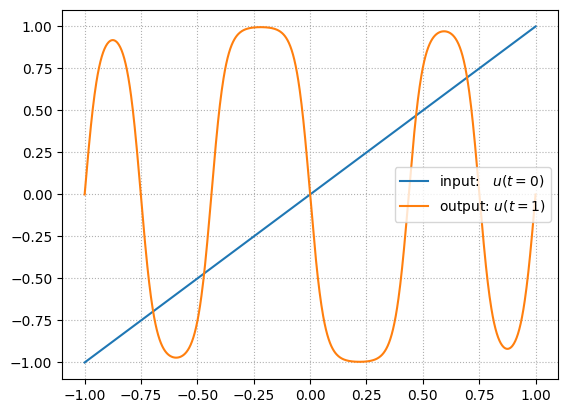

In [ ]:
id_sample = 47

plt.plot(
    np.linspace(-1, 1, input_function_train.shape[1]),
    input_function_train[id_sample, :, 0],
    label="input:   $u(t = 0)$",
)
plt.plot(
    np.linspace(-1, 1, input_function_train.shape[1]),
    output_function_train[id_sample, :],
    label="output: $u(t = 1)$",
)
plt.grid(True, which="both", ls=":")
plt.legend()

### Create Neuromancer datasets for FNO

In [12]:
from neuromancer.dataset import DictDataset

batch_size = 10
# Move data to device
input_function_train = input_function_train.to(device)
output_function_train = output_function_train.to(device)

# Neuromancer DictDatasets
train_ds = DictDataset(
    {"x": input_function_train, "y": output_function_train}, name="train"
)
dev_ds = DictDataset({"x": input_function_val, "y": output_function_val}, name="dev")
test_ds = DictDataset(
    {"x": input_function_test, "y": output_function_test}, name="test"
)

# DataLoaders
train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=batch_size, shuffle=True, collate_fn=train_ds.collate_fn
)
dev_loader = torch.utils.data.DataLoader(
    dev_ds, batch_size=batch_size, shuffle=False, collate_fn=dev_ds.collate_fn
)
test_loader = torch.utils.data.DataLoader(
    test_ds, batch_size=batch_size, shuffle=False, collate_fn=test_ds.collate_fn
)

### Fourier Neural Operator
We first make the 1D spectral/fourier layer. The Fourier layer consists of three steps:
- Fourier transform $\mathcal{F}$ (`torch.fft.rfft`)
- Linear transform on the lower Fourier modes $\mathbf{R}$ (`compl_mul1d`)
- Inverse Fourier transform $\mathcal{F}^{-1}$ (`torch.fft.irfft`)

In [ ]:
class SpectralConv1d(nn.Module):
    """
    1D Fourier layer. It does FFT, linear transform, and Inverse FFT.
    Taken from: https://colab.research.google.com/drive/1DBZW3AYwzQaxUoXjRxNQml7ClUQFJCR9?usp=sharing
    """

    def __init__(self, in_channels, out_channels, modes1):
        """
        :param in_channels: (int) dimensionality of input
        :param out_channels: (int) dimensionality of output
        :param modes1: (int) number of modes to keep (highest frequencies)
        """
        super(SpectralConv1d, self).__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1

        self.scale = 1 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(
            self.scale
            * torch.rand(in_channels, out_channels, self.modes1, dtype=torch.cfloat)
        )

    # Complex multiplication
    def compl_mul1d(self, input, weights):
        """
        1D complex multiplication
        :param input: (torch.Tensor, shape=[batch, in_channel, x]) Input in Fourier space
        :param weights: (torch.Tensor, shape=[in_channel, out_channel, x]) Weights in Fourier space
        :return: (torch.Tensor, shape=[batch, out_channel, x]) Output in Fourier space
        """
        # (batch, in_channel, x ), (in_channel, out_channel, x) -> (batch, out_channel, x)
        return torch.einsum("bix,iox->box", input, weights)

    def forward(self, x):
        """
        1D Fourier layer forward function
        :param x: (torch.Tensor, shape=[batchsize, in_channels, number of grid points])
        Input in physical space
        :return: (torch.Tensor, shape=[batchsize, out_channels, number of grid points])
        Output in physical space
        """
        batchsize = x.shape[0]
        # use DFT to approximate the fourier transform
        # Compute Fourier coefficients
        x_ft = torch.fft.rfft(x, dim=-1)  # check dim=-1

        # Multiply relevant Fourier modes
        out_ft = torch.zeros(
            batchsize,
            self.out_channels,
            x.size(-1) // 2 + 1,
            device=x.device,
            dtype=torch.cfloat,
        )
        out_ft[:, :, : self.modes1] = self.compl_mul1d(
            x_ft[:, :, : self.modes1], self.weights1
        )

        # Return to physical space
        x = torch.fft.irfft(out_ft, n=x.size(-1), dim=-1)  # check dim=-1
        return x


The FNO1d uses SpectralConv1d as its crucial part.

1. Lifting Layer ($P$)
The input $a(x)$ is augmented with the spatial grid $x$ to provide the model with geometric context. The code defines this as:
$$v_0(x) = P([u(x, 0), x])$$
Where $P$ is the `self.linear_p` layer, lifting the 2-channel input to a latent dimension (`width`) $d_{f}$.

2. Iterative Fourier Layers
The core of the model consists of three consecutive blocks. For each layer $l$, the update is defined by the combination of a Spectral Convolution and a Pointwise Convolution:
$$v_{l+1}(x) = \sigma \left( \mathcal{K}(v_l) + W v_l \right)$$

- Spectral Convolution ($\mathcal{K}$): Performed by `self.spect1, 2, 3`. It transforms the signal to the frequency domain using `SpectralConv1d`, applies learnable complex weights $R$ (`self.weights1` in `SpectralConv1d`) to the lower modes, and transforms it back:
$$\mathcal{K}(v_l) = \mathcal{F}^{-1} \left( R \cdot \mathcal{F}(v_l) \right)$$

- Pointwise Convolution ($W$): Performed by `self.lin0, 1, 2`. This is a $1 \times 1$ convolution (a residual-like connection) that helps recover local information.

- Activation ($\sigma$): Your implementation uses the Tanh() activation function.

3. Projection Layer ($Q$)
Finally, the latent representation is projected back to the output dimension through two linear transformations (self.linear_q and self.output_layer):
$$u(x, t=1) = Q_{out}(Q_{32}(v_L(x)))$$

This maps the high-dimensional hidden features back to the 1D physical scalar field of the Allen-Cahn solution.

In [ ]:
class FNO1d(nn.Module):
    """
    The overall network. It contains 4 layers of the Fourier layer.
    1. Lift the input to the desire channel dimension by self.fc0 .
    2. 4 layers of the integral operators u' = (W + K)(u).
        W defined by self.w; K defined by self.conv .
    3. Project from the channel space to the output space by self.fc1 and self.fc2 .
    """

    def __init__(self, modes, width):
        """
        input: the solution of the initial condition and location (a(x), x)
        input shape: (batchsize, x=s, c=2)
        output: the solution of a later timestep
        output shape: (batchsize, x=s, c=1)
        """
        super(FNO1d, self).__init__()

        self.modes1 = modes
        self.width = width
        self.padding = 1  # pad the domain if input is non-periodic
        self.linear_p = nn.Linear(
            2, self.width
        )  # input channel is 2: (u0(x), x) --> GRID IS INCLUDED!

        self.spect1 = SpectralConv1d(self.width, self.width, self.modes1)
        self.spect2 = SpectralConv1d(self.width, self.width, self.modes1)
        self.spect3 = SpectralConv1d(self.width, self.width, self.modes1)
        self.lin0 = nn.Conv1d(self.width, self.width, 1)
        self.lin1 = nn.Conv1d(self.width, self.width, 1)
        self.lin2 = nn.Conv1d(self.width, self.width, 1)

        # The first part of the projection (Width -> 32)
        self.linear_q = nn.Linear(self.width, 32)
        # The final part of the projection (32 -> 1)
        self.output_layer = nn.Linear(32, 1)

        self.activation = torch.nn.Tanh()

    def fourier_layer(self, x, spectral_layer, conv_layer):
        """
        :param x: (torch.Tensor, shape=[batchsize, in_channels, number of grid points]) Input in physical space
        :param spectral_layer: (nn.Module) Spectral convolutional layer
        :param conv_layer: (nn.Module) Pointwise convolutional layer
        :return: (torch.Tensor, shape=[batchsize, out_channels, number of grid points]) Output in physical space
        """
        return self.activation(spectral_layer(x) + conv_layer(x))

    def linear_layer(self, x, linear_transformation):
        return self.activation(linear_transformation(x))

    def forward(self, x):
        # grid = self.get_grid(x.shape, x.device)
        # x = torch.cat((x, grid), dim=-1)
        x = self.linear_p(x)
        # 1. Prepare for Linear layers
        # Fourier layers use (Batch, Channels, Space),
        # but Linear layers need (Batch, Space, Channels)
        x = x.permute(0, 2, 1)

        # x = F.pad(x, [0, self.padding])  # pad the domain if input is non-periodic

        x = self.fourier_layer(x, self.spect1, self.lin0)
        x = self.fourier_layer(x, self.spect2, self.lin1)
        x = self.fourier_layer(x, self.spect3, self.lin2)

        # x = x[..., :-self.padding]  # pad the domain if input is non-periodic
        # This maps 'width' channels down to 32 and applies Tanh
        x = x.permute(0, 2, 1)

        x = self.linear_layer(x, self.linear_q)
        x = self.output_layer(x)
        return x


In [ ]:
# initialise FNO model
modes = 16
width = 64
fno_model = FNO1d(modes, width).to(device)  # model

In [21]:
from neuromancer.system import Node

# symbolic wrapper of the FNO
fno_node = Node(fno_model, ["x"], ["y_fno"], name="fno_model")

In [22]:
print("symbolic inputs  of the fno_node:", fno_node.input_keys)
print("symbolic outputs of the fno_node:", fno_node.output_keys)

symbolic inputs  of the fno_node: ['x']
symbolic outputs of the fno_node: ['y_fno']


In [ ]:
# check device for train data
print(train_ds.datadict["y"].device)
# Check shapes match (Input vs Forward Pass Output)
print(f"Input training shape: {train_ds.datadict['y'].shape}")
print(f"Forward Pass on Train data shape: {fno_node(train_ds.datadict)['y_fno'].shape}")

cuda:0
Input training shape: torch.Size([128, 1001])
Forward Pass on Train data shape: torch.Size([128, 1001, 1])


# Generate MSE loss for loss evaluation 
We use L2 loss for training and evaluation
MSE loss

$$
\|y - y_h\|_{L^2(\Omega)}^2.
$$

Approach 1: Formulate the MSE loss definition with simple Neuromancer wrappers. Apply constraints on `variable` 

In [ ]:
from neuromancer.constraint import variable

# Inputs from your datadict
y_true = variable("y")
y_hat_fno = variable("y_fno")

# Value (L2) match and gradient (L2) matches; ^2 sets the L2 norm
val_constraint = (y_hat_fno == y_true) ^ 2
val_constraint.update_name("l2_value")


Approach 2: Wrap the residuals with `Objective` and minimise 

In [31]:
from neuromancer.constraint import Objective

# Approach 2: Using Objective
residual_l2 = y_hat_fno - y_true
l2_obj = Objective(residual_l2**2, metric=torch.mean, name="l2_loss")

### Setup FNO problem and Trainer 

In [32]:
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem

# aggregate list of objective terms and constraints
# objectives_fno = [val_constraint, x_grad_constraint, y_grad_constraint] #Approach 1
objectives_fno = [l2_obj]  # Approach 2
constraints_fno = []
# create constrained optimization loss
loss_fno = PenaltyLoss(objectives_fno, constraints_fno)

# construct the FNO supervised training problem
problem_fno = Problem(nodes=[fno_node], loss=loss_fno)

### Show problem FNO

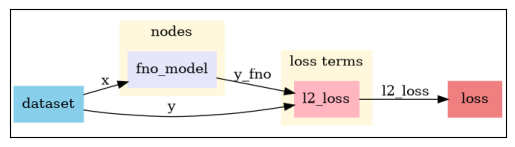

In [27]:
# Visualize the problem graph. Note: must have graphviz installed in the system
problem_fno.show()

### Train FNO purely data driven - using 20 samples of 16 x 16 data

In [28]:
from neuromancer.trainer import Trainer

optimizer = torch.optim.AdamW(problem_fno.parameters(), lr=1e-2, weight_decay=1e-4)
epochs = 50

#  Neuromancer trainer
trainer = Trainer(
    problem_fno.to(device),
    train_loader,
    optimizer=optimizer,
    epochs=epochs,
    epoch_verbose=10,
    train_metric="train_loss",
    dev_metric="train_loss",
    eval_metric="train_loss",
    warmup=epochs,
    device=device,
)

In [29]:
# Train FNO
best_model = trainer.train()

# load best trained model
problem_fno.load_state_dict(best_model)

RuntimeError: The size of tensor a (1001) must match the size of tensor b (10) at non-singleton dimension 1

## Visualizing predictions

### Zero-shot super-resolution evaluation
One of the key advantages of neural operators is their resolution invariance. We can test on 32 x 32 grid directly from a 16x16 training of the FNO

In [25]:
# evaluate trained FNO on test data
fno_out = problem_fno.nodes[0].cpu()
fno_model_out = fno_out(test_ds_fno.datadict)  # now on 32x32 grid

# evaluate forward pass on the train data
fno_model_out["y_fno"].shape

torch.Size([10, 1, 32, 32])

/tmp/ipykernel_263851/32698566.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


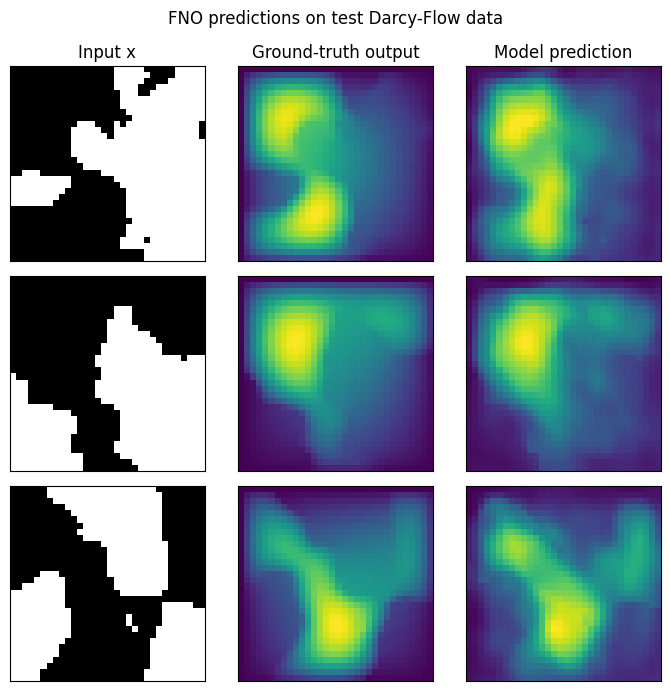

In [26]:
# Get predictions from the trained FNO on the stacked test set
fno_eval = problem_fno.nodes[0].cpu()  # ensure model on CPU for plotting
with torch.no_grad():
    preds = fno_eval(test_ds_fno.datadict)["y_fno"].cpu()

fig = plt.figure(figsize=(7, 7))
for index in range(3):
    sample = test_ds_fno[index]  # {'x_grid': ..., 'y_grid': ...}
    x = sample["x_grid"].cpu()
    y = sample["y_grid"].cpu()
    out = preds[index]  # model output from problem_fno

    ax = fig.add_subplot(3, 3, index * 3 + 1)
    ax.imshow(x[0], cmap="gray")
    if index == 0:
        ax.set_title("Input x")
    plt.xticks([], [])
    plt.yticks([], [])

    ax = fig.add_subplot(3, 3, index * 3 + 2)
    ax.imshow(y.squeeze())
    if index == 0:
        ax.set_title("Ground-truth output")
    plt.xticks([], [])
    plt.yticks([], [])

    ax = fig.add_subplot(3, 3, index * 3 + 3)
    ax.imshow(out.squeeze().detach().numpy())
    if index == 0:
        ax.set_title("Model prediction")
    plt.xticks([], [])
    plt.yticks([], [])

fig.suptitle("FNO predictions on test Darcy-Flow data", y=0.98)
plt.tight_layout()
fig.show()


### Testing on 16 x 16 dataset

In [27]:
# Example test loader (pick one resolution index)
res = 16  # 16 or 32
batch_size_test = 4
xs_t, ys_t = [], []
for i in range(len(dataset.test_dbs[res])):
    sample = dataset.data_processor.preprocess(dataset.test_dbs[res][i], batched=False)
    xs_t.append(sample["x"])
    ys_t.append(sample["y"].squeeze(0))  # [1, H, W]

x_test = torch.stack(xs_t)  # [N, 1, 16, 16]
y_test = torch.stack(ys_t)  # [N, 1, H, W]

test_ds_fno = DictDataset({"x_grid": x_test, "y_grid": y_test}, name=f"test{res}")
test_loader_fno = torch.utils.data.DataLoader(
    test_ds_fno,
    batch_size=batch_size_test,  # match your test batch size
    shuffle=False,
    collate_fn=test_ds_fno.collate_fn,
)

In [28]:
# evaluate trained FNO on test data
fno_out = problem_fno.nodes[0].cpu()
fno_model_out = fno_out(test_ds_fno.datadict)  # now on 32x32 grid

# evaluate forward pass on the train data
fno_model_out["y_fno"].shape

torch.Size([10, 1, 16, 16])

/tmp/ipykernel_263851/3574052000.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


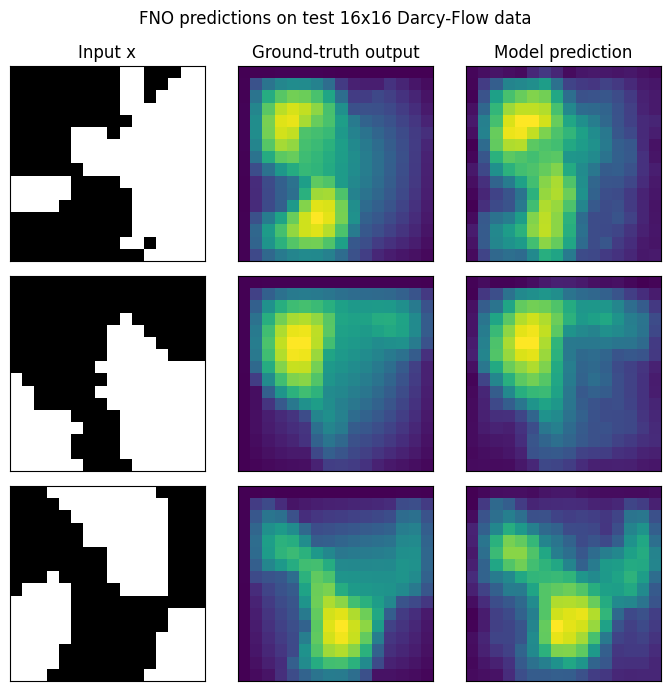

In [29]:
# Get predictions from the trained FNO on the stacked test set
fno_eval = problem_fno.nodes[0].cpu()  # ensure model on CPU for plotting
with torch.no_grad():
    preds = fno_eval(test_ds_fno.datadict)["y_fno"].cpu()

fig = plt.figure(figsize=(7, 7))
for index in range(3):
    sample = test_ds_fno[index]  # {'x_grid': ..., 'y_grid': ...}
    x = sample["x_grid"].cpu()
    y = sample["y_grid"].cpu()
    out = preds[index]  # model output from problem_fno

    ax = fig.add_subplot(3, 3, index * 3 + 1)
    ax.imshow(x[0], cmap="gray")
    if index == 0:
        ax.set_title("Input x")
    plt.xticks([], [])
    plt.yticks([], [])

    ax = fig.add_subplot(3, 3, index * 3 + 2)
    ax.imshow(y.squeeze())
    if index == 0:
        ax.set_title("Ground-truth output")
    plt.xticks([], [])
    plt.yticks([], [])

    ax = fig.add_subplot(3, 3, index * 3 + 3)
    ax.imshow(out.squeeze().detach().numpy())
    if index == 0:
        ax.set_title("Model prediction")
    plt.xticks([], [])
    plt.yticks([], [])

fig.suptitle("FNO predictions on test 16x16 Darcy-Flow data", y=0.98)
plt.tight_layout()
fig.show()
